In [184]:
from phidl import Path, CrossSection, Device, Layer, quickplot
import phidl.path as pp
import phidl.geometry as pg
import phidl.routing as pr
import numpy as np

from phidl import Path, CrossSection, Device
import phidl.path as pp
import numpy as np
from phidl import Device, Layer, quickplot
import phidl.geometry as pg
import phidl.routing as pr
from phidl import set_quickplot_options
set_quickplot_options(show_subports=False, interactive_zoom=True)

In [185]:
### borderlines ###

def make_border(wt, ht, th, wg_func):
    B = Device()
    # 아래
    B.add_ref(wg_func(width=wt, height=th))

    # 위
    top = B.add_ref(wg_func(width=wt, height=th))
    top.move([0, ht-th])

    # 왼쪽
    B.add_ref(wg_func(width=th, height=ht))

    # 오른쪽
    right = B.add_ref(wg_func(width=th, height=ht))
    right.move([wt-th, 0])

    # 중심 정렬
    B.move((-wt/2, -ht/2))

    return B

### waveguides definek ### 

def waveguide(width = 10, height = 1):
    WG = Device('waveguide')
    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=3)
    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
    return WG

def waveguide_l1(width = 10, height = 1):
    WG = Device('waveguide')
    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=1)
    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
    return WG
def waveguide_l2(width = 10, height = 1):
    WG = Device('waveguide')
    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=2)
    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
    return WG
def waveguide_l4(width = 10, height = 1):
    WG = Device('waveguide')
    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=4)
    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
    return WG
def waveguide_l5(width = 10, height = 1):
    WG = Device('waveguide')
    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=5)
    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
    return WG

def waveguide_l(width = 10, height = 1, layer=3):
    WG = Device('waveguide')
    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=layer)
    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
    return WG

In [186]:
### FP resonator define ###

def Bragg_reflector_square(m_tap, m_brag, period, wwg1, wwg2, wg, layer, duty):
    FL = Device()
    tap_length = m_tap * period

    def create_unit_cell(val, length):
        FL2 = Device()
        P = Path()
        P.append(pp.straight(length))
        X = CrossSection()

        def bragg_width(t):
            if val < tap_length:
                taper_ratio = (np.sin((np.clip(val / tap_length, 0, 1) - 0.5) * np.pi) + 1) / 2
                taper_ratio_l = (np.sin((np.clip((val + length) / tap_length, 0, 1) - 0.5) * np.pi) + 1) / 2
                wwg_local = wwg1 + taper_ratio * (wwg2 - wwg1) * (1 - t) + taper_ratio_l * (wwg2 - wwg1) * t
                wt_local = taper_ratio * wg * (1 - t) + taper_ratio_l * wg * t
            else:
                wwg_local = wwg2
                wt_local = wg

            return 2 * wt_local * (
                np.heaviside(t - (0.5 - duty / 2), 1)
                - np.heaviside(t - (0.5 + duty / 2), 1)
            ) + wwg_local

        X.add(width=bragg_width, offset=0, layer=layer, ports=('in1', 'out1'))
        Ref = P.extrude(X, simplify=1e-3)
        FL2.add_ref(Ref)
        return pg.union(FL2, by_layer=False, precision=0.0001, max_points=8000, layer=layer)

    cell1 = int(m_tap)
    cell2 = int(m_brag)
    lengthx = 0
    RX = 0

    In = Device()
    Brag = Device()

    for _ in range(cell1):
        unit_cell = In << create_unit_cell(lengthx, period - 0.005)
        unit_cell.x = RX
        RX += period
        lengthx += period

    for _ in range(cell2):
        unit_cell = Brag << create_unit_cell(lengthx, period - 0.005)
        unit_cell.x = RX
        RX += period
        lengthx += period

    Out = Device()
    out = Out.add_ref(In)
    out.mirror([0, 1])
    out.xmin = Brag.xmax + 0.005

    FL << In
    FL << Brag
    FL << Out

    EL2 = pg.union(FL, by_layer=False, layer=layer)
    EL2.add_port(name='wgport1', midpoint=[EL2.xmin + 0.05, EL2.y], width=wwg1, orientation=180)
    EL2.add_port(name='wgport2', midpoint=[EL2.xmax - 0.05, EL2.y], width=wwg1, orientation=0)

    return EL2

def add_side_bars(parent, reso, left_len, right_len, yoff=4.25, h=2, ext=5, layer=4):
    # left upper
    bar = parent.add_ref(waveguide_l(width=left_len, height=h))#, layer=layer))
    bar.y = reso.y + yoff
    bar.xmin = reso.xmin - ext

    # left lower
    bar = parent.add_ref(waveguide_l(width=left_len, height=h))#, layer=layer))
    bar.y = reso.y - yoff
    bar.xmin = reso.xmin - ext

    # right upper
    bar = parent.add_ref(waveguide_l(width=right_len, height=h))#, layer=layer))
    bar.y = reso.y + yoff
    bar.xmax = reso.xmax + ext

    # right lower
    bar = parent.add_ref(waveguide_l(width=right_len, height=h))#, layer=layer))
    bar.y = reso.y - yoff
    bar.xmax = reso.xmax + ext

def FP_resonator_1(m_tap, m_brag1, m_brag2, period, 
                   wwg1, wwg2, wg, length, w_reso, l_taper,
                   layer, duty):

    FL=Device()

    PhR_l=FL.add_ref(Bragg_reflector_square(m_tap, m_brag1, period, wwg1, wwg2, wg, layer, duty))
    PhR_l.mirror([0,1])
    PhR_r=FL.add_ref(Bragg_reflector_square(40, m_brag2, period, wwg1, wwg2, wg, layer, duty))
    PhR_r.y=PhR_l.y
    PhR_r.xmin=PhR_l.xmax+l_taper*2+length

    wgtp=FL.add_ref(waveguide(width = length, height=w_reso))
    wgtp.y = PhR_l.y
    wgtp.x=PhR_l.xmax+(l_taper*2+length)/2

    FL.add_ref(pr.route_smooth(port1 = PhR_l.ports['wgport1'], 
                               port2 = wgtp.ports['wgport1'], 
                               path_type = 'manhattan', width_type = 'sine',layer=3))
    FL.add_ref(pr.route_smooth(port1 = PhR_r.ports['wgport1'], 
                               port2 = wgtp.ports['wgport2'], 
                               path_type = 'manhattan', width_type = 'sine',layer=3))
    PhR_l.xmin=PhR_l.xmin+0.05
    PhR_r.xmax=PhR_r.xmax-0.05

    FL.add_port(name='wgport1', midpoint=[PhR_l.xmin+0.05, PhR_l.y], width=wwg1, orientation=180)
    FL.add_port(name='wgport2', midpoint=[PhR_r.xmax-0.05, PhR_l.y], width=wwg1, orientation=0)

    return FL

def FP_resonator_nr_v1(mtp1, mtp2, mbr1, mbr2, period,
                       wwg1, wwg2, wgmod,
                       lres, wres, ltap,
                       layer, duty,
                       sidebar = True):

    FL = Device()

    # left Bragg
    phr_l = FL.add_ref(Bragg_reflector_square(mtp1, mbr1, period, wwg1, wwg2, wgmod, layer, duty))
    phr_l.mirror([0, 1])
    # right Bragg
    phr_r = FL.add_ref(Bragg_reflector_square(mtp2, mbr2, period, wwg1, wwg2, wgmod, layer, duty))
    phr_r.y = phr_l.y
    phr_r.xmin = phr_l.xmax + 2 * ltap + lres

    # center waveguide
    wg_mid = FL.add_ref(waveguide_l(width=lres, height=wres, layer=layer))
    wg_mid.y = phr_l.y
    wg_mid.x = phr_l.xmax + (2 * ltap + lres) / 2

    # inner tapered connections i.e. Bragg <-> cavity
    FL.add_ref(pr.route_smooth(
        port1=phr_l.ports['wgport1'],
        port2=wg_mid.ports['wgport1'],
        path_type='manhattan',
        width_type='sine',
        layer=layer
    ))
    phr_l.xmin=phr_l.xmin+0.05

    FL.add_ref(pr.route_smooth(
        port1=phr_r.ports['wgport1'],
        port2=wg_mid.ports['wgport2'],
        path_type='manhattan',
        width_type='sine',
        layer=layer
    ))
    phr_r.xmax=phr_r.xmax-0.05

    FL.add_port(name='wgport1', midpoint=[phr_l.xmin+0.05, phr_l.y], width=wwg1, orientation=180)
    FL.add_port(name='wgport2', midpoint=[phr_r.xmax-0.05, phr_l.y], width=wwg1, orientation=0)

    if sidebar:
        h = 2
        yoff = 4.25

        left_len = (mbr1 + 2 * mtp1) * period + 10
        right_len = (mbr2 + 2 * mtp2) * period + 10

        for length, x0 in [(left_len, phr_l.x), (right_len, phr_r.x)]:
            rect = pg.rectangle((length, h), layer=layer)
            for dy in (+yoff, -yoff):
                bar = FL.add_ref(rect)
                bar.center = (x0, wg_mid.y + dy)

    return FL




In [187]:
### PPLN Electrode Define ###

ppln_length = 2000

def electrode_pad(width=200, height=200, layer=4):
    P = Device('pad')
    P.add_polygon(
        [(0,0), (width,0), (width,height), (0,height)],
        layer=layer
    )
    return P

def eo_pad(width=70, height=70, layer=4):
    P = Device('pad')
    P.add_polygon(
        [(0,0), (width,0), (width,height), (0,height)],
        layer=layer
    )
    return P

def finger(finger_l, finger_w, tip_len = 2, layer=4):
    F = Device('finger')
    poly = [
        (-finger_w/2, 0),
        (-finger_w/2, finger_l - tip_len),
        (0, finger_l),
        ( finger_w/2, finger_l - tip_len),
        ( finger_w/2, 0)
    ]

    F.add_polygon(poly, layer=layer)
    return F


def poling_comb_bottom(
    length=ppln_length,
    period=3,
    finger_w=0.6,
    finger_l=30,
    tip_len=2,
    gap=3.6,
    offset=2,
    layer=4
):
    D_EO = Device('poling_comb')

    N = int((ppln_length - finger_w) / period)

    f = finger(finger_l, finger_w, tip_len, layer)
    for i in range(N):
        ref = D_EO.add_ref(f)
        ref.x = i * period
        ref.y = offset
    
    return D_EO

pad_dev  = electrode_pad(ppln_length, 15, layer=4)

comb_bot = poling_comb_bottom(
    length=ppln_length,
    period=3.4,
    finger_w=0.6,
    finger_l=30,
    offset=0,
    layer=4
)

comb_top = poling_comb_bottom(
    length=ppln_length,
    period=3.4,
    finger_w=0.6,
    finger_l=30,
    offset=0,
    layer=4
)
comb_top.mirror([1,0])

eo_top = eo_pad(width=70, height=70, layer=4)
eo_bot = eo_pad(width=70, height=70, layer=4)

A = Device('electrode_assembly')

pad_bot  = A.add_ref(pad_dev)
comb_bot = A.add_ref(comb_bot)
eo_bot = A.add_ref(eo_bot)

pad_top  = A.add_ref(pad_dev)
comb_top = A.add_ref(comb_top)   
eo_top = A.add_ref(eo_top)

res_cen = (0,0)
el_size = 110

pad_bot.x = res_cen[0]
pad_top.x = res_cen[0]

pad_bot.ymin = res_cen[1] - el_size/2
pad_top.ymax = res_cen[1] + el_size/2

comb_bot.x = pad_bot.x
comb_bot.ymin = pad_bot.ymax - 2

comb_top.x = pad_top.x
comb_top.ymax = pad_top.ymin + 2

eo_bot.xmax = pad_bot.xmin
eo_bot.ymax = pad_bot.ymax + 5

eo_top.xmin = pad_top.xmax
eo_top.ymin = pad_top.ymin - 5




In [188]:
### PhC Tuning EO Electrodes Define ###

# 참고: def electrode_pad(width=200, height=200, layer=4)

EO_layer = 10

A_EO = Device('PhC Tuning')

Ground_length = 2367
Source_WG_length = 2150
Source_Coupler_length = 81.114
Source_Mirror_length = 85.754
Spacing = (Ground_length - (Source_WG_length + Source_Coupler_length + Source_Mirror_length))*1/2
print(Spacing)

EO_width = 146
EO_cen = (0,0)
Total_width = 300

pad_EO_G = electrode_pad(Ground_length, EO_width, layer=EO_layer)
pad_EO_WG = electrode_pad(Source_WG_length, EO_width, layer=EO_layer)
pad_EO_Coupler = electrode_pad(Source_Coupler_length, EO_width, layer=EO_layer)
pad_EO_Mirror = electrode_pad(Source_Mirror_length, EO_width, layer=EO_layer)

EO_Ground = A_EO.add_ref(pad_EO_G)
EO_WG = A_EO.add_ref(pad_EO_WG)
EO_Coupler = A_EO.add_ref(pad_EO_Coupler)
EO_Mirror = A_EO.add_ref(pad_EO_Mirror)

EO_Ground.x = EO_cen[0]
EO_WG.xmin = EO_cen[0] - Ground_length/2 + Source_Coupler_length + Spacing
EO_Coupler.xmin = EO_cen[0] - Ground_length/2 #+ Source_Coupler_length/2
EO_Mirror.xmax = EO_cen[0] + Ground_length/2 #- Source_Mirror_length/2

EO_Ground.ymin = EO_cen[1] - Total_width/2
EO_WG.ymax = EO_cen[1] + Total_width/2
EO_Coupler.ymax = EO_WG.ymax
EO_Mirror.ymax = EO_WG.ymax

A_EO.write_gds('EO_4_Probes_test.gds')

### Mirroring ###

A_EO_M = Device('PhC Tuning')

EO_Ground = A_EO_M.add_ref(pad_EO_G)
EO_WG = A_EO_M.add_ref(pad_EO_WG)
EO_Coupler = A_EO_M.add_ref(pad_EO_Coupler)
EO_Mirror = A_EO_M.add_ref(pad_EO_Mirror)

EO_Ground.x = EO_cen[0]
EO_WG.xmax = EO_cen[0] + Ground_length/2 - Source_Coupler_length - Spacing
EO_Coupler.xmax = EO_cen[0] + Ground_length/2 #+ Source_Coupler_length/2
EO_Mirror.xmin = EO_cen[0] - Ground_length/2 #- Source_Mirror_length/2

EO_Ground.ymin = EO_cen[1] - Total_width/2
EO_WG.ymax = EO_cen[1] + Total_width/2
EO_Coupler.ymax = EO_WG.ymax
EO_Mirror.ymax = EO_WG.ymax

25.06600000000003


In [189]:
### Reza Code ###

#K=Device()

#def waveguide2(width = 10, height = 1):
#    WG = Device('waveguide')
#    WG.add_polygon( [(0, 0), (width, 0), (width, height), (0, height)] ,layer=1)
#    WG.add_port(name = 'wgport1', midpoint = [0,height/2], width = height, orientation = 180)
#    WG.add_port(name = 'wgport2', midpoint = [width,height/2], width = height, orientation = 0)
#    return WG

#def comb(Period=2, L = 20,width=1):
#    EL = Device('Electrode')
#    EL.add_ref(waveguide2(width=width,height=40))
#    COM=Device("com")
#    A1=COM.add_array(EL,columns = np.int(L/Period), rows = 1, spacing = [Period,1])
#    return COM

#B_Reza=Device('Comb')
#temp_Reza_B=Device()
#temp_Reza_C=Device()
#C_Reza=Device('Pad')
#K=Device('Box')
#Box=Device()
#temp_Reza_B<<K
#temp_Reza_C<<K
#X=Device()
#X.x=0
#X.y=0
#X.add_ref(B_Reza)
#X.write_gds('260325_Reza_PPLN_Test.gds')

In [190]:
def to_region(width=ppln_length, height=150, layer=100):
    P = Device('pad')
    P.add_polygon(
        [(0,0), (width,0), (width,height), (0,height)],
        layer=layer
    )
    return P

In [191]:
to_region = to_region(width=ppln_length, height = 150, layer= 100)

to_region = A.add_ref(to_region)
to_region.x = res_cen[0]
to_region.ymax = res_cen[1] - 3 # wg3um 기준, 오차범위 감안 2배

A.write_gds('electrode_assembly_test.gds')

'electrode_assembly_test.gds'

In [192]:
### PPLN variables ###

sample_size = (22000, 12000)
buffer = (2000, 2000)
num_hor = 3
hor_size = (sample_size[0] - (2+(num_hor-1))*buffer[0])/num_hor
ver_size = sample_size[1] - 4*buffer[1]
num_ver = ver_size//260

print(hor_size)
print(ver_size)
print(num_ver)

4666.666666666667
4000
15


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


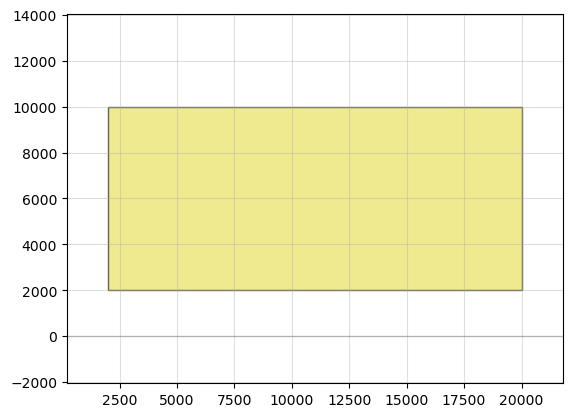

In [193]:
### Chip 상태 확인 ###

from phidl import Device
from phidl.geometry import rectangle
from phidl import geometry as pg

def die_outline(width, height, layer=10, xbuffer=5, ybuffer=5):
    D_EO = Device('die_outline')

    outer = rectangle(size=(width, height), layer=layer)
    inner = rectangle(
        size=(width - 2*xbuffer, height - 2*ybuffer),
        layer=3
    )

    o = D_EO.add_ref(outer)
    i = D_EO.add_ref(inner)
    i.center = o.center

    pg.boolean(o, i, operation='A-B', layer=layer)

    return D_EO, i

D_EO,i = die_outline(width = 22000, height= 12000, layer = 2, xbuffer=2000, ybuffer=2000)

quickplot(i)

In [194]:
### WG variables ###

# placement
edge_margin = 500
align_margin = 150
device_margin = 200

# routing length
lbus = 1500    # left bus length
rbus = 2000    # right bus length
ltest = 5000   # long routing/test line

# waveguide width
wbus = 2.8
wacc = 0.9

# borderline
cw, ch = 22000, 12000   # chip size
dw, dh = 18000, 8000    # device size

# resonator
lres = 2000
wres = 2
ltap = 100

# bragg
period = 0.430
mtp1 = 40
mtp2 = 40
mbr1 = 109
mbr2 = 120

wwg1 = 2
wwg2 = 1
wgmod = 1.1

duty = 0.35

In [195]:
rx = 2200
RX = [rx, dw / 2, dw - rx]
RY0 = edge_margin + align_margin + device_margin
gap = 85


buffer_l, buffer_r = 1500, 2000

reso_temp_x = FP_resonator_nr_v1(
    mtp1, mtp2, mbr1, mbr2, period,
    wwg1, wwg2, wgmod,
    lres, wres, ltap,
    layer=3, duty=duty, sidebar=True
)

reso_temp_o = FP_resonator_nr_v1(
    mtp1, mtp2, mbr1, mbr2, period,
    wwg1, wwg2, wgmod,
    lres, wres, ltap,
    layer=3, duty=duty, sidebar=False
)

ybox = reso_temp_x.ysize + 2 * gap
nrow = int((dh - 2 * RY0) / ybox)

# build border
B = Device('border')
big_box = B.add_ref(make_border(cw, ch, 5, waveguide_l2))
small_box = B.add_ref(make_border(dw, dh, 1, waveguide_l))

def make_bus(parent, specs, width, layer=3):
    P = Path()
    for kind, *args in specs:
        if kind == 'straight':
            P.append(pp.straight(*args))
        elif kind == 'euler':
            P.append(pp.euler(*args))

    X = CrossSection()
    X.add(width=width, offset=0, layer=layer, ports=('wgport1', 'wgport2'))
    return parent.add_ref(P.extrude(X))


def add_route(parent, port1, port2, layer=3):
    parent.add_ref(
        pr.route_smooth(
            port1=port1,
            port2=port2,
            path_type='manhattan',
            width_type='sine',
            layer=layer
        )
    )


left_bus_specs = [
    ('straight', 900),
    ('euler', 150, -25, 0.5),
    ('euler', 150, 25, 0.5),
    ('straight', 1200),
    ('euler', 150, 25, 0.5),
    ('euler', 150, -25, 0.5),
]

right_bus_specs = [
    ('straight', 2000),
    ('euler', 150, 25, 0.5),
    ('euler', 150, -25, 0.5),
    ('straight', 300),
]



In [196]:
x_line = None
y_cut = [[], [], [], [], [], []]
Dx = Device('resonator_x')
for i in range(nrow):

    row_y = RY0 + i * ybox

    # -------------------------
    # left resonator
    # -------------------------
    res_left = Dx.add_ref(reso_temp_x)
    res_left.xmin = RX[0]
    res_left.ymin = row_y
    tlt=Dx.add_ref(pg.text("1_"+str(i+1),size=20,layer=3))
    tlt.ymin = res_left.ymin - 50
    tlt.x = res_left.x

    bus_left_mid = make_bus(Dx, left_bus_specs, wbus)
    bus_left_mid.ymax = res_left.y + wbus/2
    bus_left_mid.xmin = res_left.xmax + 300

    # left-middle bus 직선부 centerline y
    y_bus_left = bus_left_mid.ymax - wbus/2
    dy = bus_left_mid.ymax - bus_left_mid.ymin - wbus

    # -------------------------
    # right resonator
    # -------------------------
    res_right = Dx.add_ref(reso_temp_x)
    res_right.mirror([0,1])
    res_right.xmax = RX[2]
    res_right.ymin = row_y + dy
    tlt=Dx.add_ref(pg.text("3_"+str(i+1),size=20,layer=3))
    tlt.ymin = res_right.ymin - 50
    tlt.x = res_right.x

    bus_mid_right = make_bus(Dx, right_bus_specs, wbus)
    bus_mid_right.ymax = res_right.y + wbus/2
    bus_mid_right.xmax = res_right.xmin - 300

    # middle-right bus 직선부 centerline y
    y_bus_right = bus_mid_right.ymax - wbus/2

    # -------------------------
    # center resonator
    # -------------------------
    res_mid = Dx.add_ref(reso_temp_x)
    res_mid.x = RX[1]
    res_mid.ymin = row_y
    tlt=Dx.add_ref(pg.text("2_"+str(i+1),size=20,layer=3))
    tlt.ymin = res_mid.ymin - 50
    tlt.x = res_mid.x

    # -------------------------
    # edge buffers
    # -------------------------
    wg_left = Dx.add_ref(waveguide(width=buffer_l, height=wbus))
    wg_left.xmin = 0
    wg_left.y = res_left.y

    wg_right = Dx.add_ref(waveguide(width=buffer_r, height=wbus))
    wg_right.xmax = dw
    wg_right.y = res_right.y

    # -------------------------
    # x 좌표는 첫 row에서만 저장
    # -------------------------
    if x_line is None:
        x_line = [
            wg_left.x+250,         # 1
            bus_left_mid.x,    # 2
            bus_left_mid.x+900,
            bus_mid_right.x-550,   # 3
            bus_mid_right.x+450,
            wg_right.x         # 4
        ]

    # -------------------------
    # 각 vertical line별 cut y
    # -------------------------
    y_cut[0].append(wg_left.y)           #1
    y_cut[1].append(bus_left_mid.ymin)   #2
    y_cut[2].append(bus_left_mid.ymin)   #2_2
    y_cut[3].append(wg_left.y)           #3
    y_cut[4].append(wg_left.y)           #3_2
    y_cut[5].append(wg_right.y)          #4

    # -------------------------
    # routing
    # -------------------------
    add_route(Dx, res_left.ports['wgport1'], wg_left.ports['wgport2'])
    add_route(Dx, res_left.ports['wgport2'], bus_left_mid.ports['wgport1'])

    add_route(Dx, res_right.ports['wgport1'], wg_right.ports['wgport1'])
    add_route(Dx, res_right.ports['wgport2'], bus_mid_right.ports['wgport2'])

    add_route(Dx, res_mid.ports['wgport1'], bus_left_mid.ports['wgport2'])
    add_route(Dx, res_mid.ports['wgport2'], bus_mid_right.ports['wgport1'])

In [197]:
def make_allowed_intervals(y_list, dh, clearance):
    blocked = []
    for y in sorted(set(y_list)):
        y0 = max(0, y - clearance)
        y1 = min(dh, y + clearance)
        blocked.append((y0, y1))

    blocked.sort()
    merged = []
    for y0, y1 in blocked:
        if not merged or y0 > merged[-1][1]:
            merged.append([y0, y1])
        else:
            merged[-1][1] = max(merged[-1][1], y1)

    allowed = []
    cursor = 0
    for y0, y1 in merged:
        if y0 > cursor:
            allowed.append((cursor, y0))
        cursor = y1

    if cursor < dh:
        allowed.append((cursor, dh))

    return allowed

In [198]:
line_w = 1
line_gap = 5
clearance = 10

for idx, x in enumerate(x_line):
    allowed = make_allowed_intervals(y_cut[idx], dh, clearance)

    for y0, y1 in allowed:
        h = y1 - y0
        if h <= 0:
            continue

        r1 = Dx.add_ref(pg.rectangle((line_w, h), layer=3))
        r1.x = x - line_gap
        r1.ymin = y0

        r2 = Dx.add_ref(pg.rectangle((line_w, h), layer=3))
        r2.x = x + line_gap
        r2.ymin = y0

In [199]:
tlt=Dx.add_ref(pg.text("---->>> :    260324 PECx Chip #1",size=50,layer=3))
tlt.xmin = x_line[0] + 300
tlt.y = dh-RY0/2

tlt=Dx.add_ref(pg.text("---->>> :    260324 PECx Chip #2",size=50,layer=3))
tlt.xmin = x_line[2] + 300
tlt.ymin = dh-RY0/2

tlt=Dx.add_ref(pg.text("260324 PECx Chip #3    : <<<----",size=50,layer=3))
tlt.xmax = x_line[-1] - 300
tlt.ymin = dh-RY0/2

In [200]:
def align_mark(w=400, h=4, dot=10, gap=80, layer=3):
    """
    w   : cross bar length
    h   : cross bar thickness
    dot : dot size (square)
    gap : center-to-dot offset
    """
    D = Device('align_mark')

    # ── cross (horizontal)
    hbar = D.add_ref(
        pg.rectangle(size=(w, h), layer=layer)
    )
    hbar.center = (0, 0)

    # │ cross (vertical)
    vbar = D.add_ref(
        pg.rectangle(size=(h, w), layer=layer)
    )
    vbar.center = (0, 0)

    # ┌┐ dots (4 quadrants)
    offsets = [
        ( gap,  gap),   # Q1
        (-gap,  gap),   # Q2
        (-gap, -gap),   # Q3
        ( gap, -gap),   # Q4
    ]

    for dx, dy in offsets:
        d = D.add_ref(
            pg.rectangle(size=(dot, dot), layer=layer)
        )
        d.center = (dx, dy)

    return D

In [201]:
offsets = [
        (dw-400, dh-400),   # Q1
        (400, dh-400),   # Q2
        (400, 400),   # Q3
        (dw-400, 400),   # Q4
    ]

M = Device("marks")
align_mark = align_mark()
for dx, dy in offsets:
    d = M.add_ref(align_mark)
    d.center = (dx, dy)
    if dy == dh - 400:
        top_label = pg.text(
            text=f'top',
            size=30,
            layer=3
        )
        t = M.add_ref(top_label)
        if dx == 400:
            t.center = (dx+300, dy)
        else:
            t.center = (dx-300, dy)
    else:
        bot_label = pg.text(
            text=f'bottom',
            size=30,
            layer=3
        )
        t = M.add_ref(bot_label)
        if dx == 400:
            t.center = (dx+300, dy)
        else:
            t.center = (dx-300, dy)

In [202]:
TOP = Device('TOP')

b_ref = TOP.add_ref(B)
dx_ref = TOP.add_ref(Dx)
dx_ref.center = b_ref.center
am_ref = TOP.add_ref(M)
am_ref.center = b_ref.center

# save
#TOP.write_gds('260319_JH_PECx_KANC.gds')

In [203]:
# for TEO electrodes
blank_teo = 200

#gap = 150
ybox = reso_temp_x.ysize + 2 * gap + blank_teo*2*(1.1)
nrow = int((dh - 2 * RY0) / ybox)

In [204]:
x_line = None
y_cut = [[], [], [], [], [], []]
Do = Device('resonator_o')
for i in range(nrow+1):

    row_y = RY0 + i * ybox
    if i >= 0 and i <= 11:
        layer=3
        #dose=3000
        sidebar=False
    elif i >= 12 and i <= 23:
        layer=3
        #dose=2900
        sidebar=False
    else:
        layer=3
        #dose=2800
        sidebar=False
    reso_temp_o = FP_resonator_nr_v1(
        mtp1, mtp2, mbr1, mbr2, period,
        wwg1, wwg2, wgmod,
        lres, wres, ltap,
        layer=layer, duty=duty, sidebar=sidebar
    )

    # -------------------------
    # left resonator
    # -------------------------
    
    res_left = Do.add_ref(reso_temp_o)
    res_left.xmin = RX[0]
    res_left.ymin = row_y
    tlt=Do.add_ref(pg.text("1_"+str(i+1)+" ---->>>",size=20,layer=layer))
    tlt.ymin = res_left.ymin - 70
    tlt.xmax = res_left.xmin - 200
    tlt1=Do.add_ref(pg.text("Coupler_"+str(i+1),size=20,layer=layer))
    tlt1.ymin = res_left.ymin - 200
    tlt1.xmax = res_left.xmin + 120
    tlt1=Do.add_ref(pg.text("Mirror_"+str(i+1),size=20,layer=layer))
    tlt1.ymin = res_left.ymin - 200
    tlt1.xmax = res_left.xmin + 2395

    bus_left_mid = make_bus(Do, left_bus_specs, wbus, layer=layer)
    bus_left_mid.ymax = res_left.y + wbus/2
    bus_left_mid.xmin = res_left.xmax + 300

    # left-middle bus 직선부 centerline y
    y_bus_left = bus_left_mid.ymax - wbus/2
    dy = bus_left_mid.ymax - bus_left_mid.ymin - wbus

    # -------------------------
    # right resonator
    # -------------------------
    res_right = Do.add_ref(reso_temp_o)
    res_right.mirror([0,1])
    res_right.xmax = RX[2]
    res_right.ymin = row_y + dy
    tlt=Do.add_ref(pg.text("3_"+str(i+1)+" <<<----",size=20,layer=layer))
    tlt.ymin = res_right.ymin - 70
    tlt.xmin = res_right.xmax + 200
    tlt1=Do.add_ref(pg.text("Coupler_"+str(i+1),size=20,layer=layer))
    tlt1.ymin = res_right.ymin - 200
    tlt1.xmax = res_right.xmax + 35
    tlt1=Do.add_ref(pg.text("Mirror_"+str(i+1),size=20,layer=layer))
    tlt1.ymin = res_right.ymin - 200
    tlt1.xmax = res_right.xmax - 2255

    bus_mid_right = make_bus(Do, right_bus_specs, wbus, layer=layer)
    bus_mid_right.ymax = res_right.y + wbus/2
    bus_mid_right.xmax = res_right.xmin - 300

    # middle-right bus 직선부 centerline y
    y_bus_right = bus_mid_right.ymax - wbus/2

    # -------------------------
    # center resonator
    # -------------------------
    res_mid = Do.add_ref(reso_temp_o)
    res_mid.x = RX[1]
    res_mid.ymin = row_y
    tlt=Do.add_ref(pg.text("2_"+str(i+1)+" ---->>>",size=20,layer=layer))
    tlt.ymin = res_mid.ymin - 70
    tlt.xmax = res_mid.xmin - 200
    tlt1=Do.add_ref(pg.text("Coupler_"+str(i+1),size=20,layer=layer))
    tlt1.ymin = res_mid.ymin - 200
    tlt1.xmax = res_mid.xmin + 120
    tlt1=Do.add_ref(pg.text("Mirror_"+str(i+1),size=20,layer=layer))
    tlt1.ymin = res_mid.ymin - 200
    tlt1.xmax = res_mid.xmin + 2395

    # -------------------------
    # edge buffers
    # -------------------------
    wg_left = Do.add_ref(waveguide_l(width=buffer_l, height=wbus, layer=layer))
    wg_left.xmin = 0
    wg_left.y = res_left.y

    wg_right = Do.add_ref(waveguide_l(width=buffer_l, height=wbus, layer=layer))
    wg_right.xmax = dw
    wg_right.y = res_right.y

    # -------------------------
    # x 좌표는 첫 row에서만 저장
    # -------------------------
    if x_line is None:
        x_line = [
            wg_left.x+600,         # 1
            bus_left_mid.x,        # 2
            bus_left_mid.x+900,
            bus_mid_right.x-550,   # 3
            bus_mid_right.x+450,
            wg_right.x-350         # 4
        ]

    # -------------------------
    # 각 vertical line별 cut y
    # -------------------------
    y_cut[0].append(wg_left.y)           #1
    y_cut[1].append(bus_left_mid.ymin)   #2
    y_cut[2].append(bus_left_mid.ymin)   #2_2
    y_cut[3].append(wg_left.y)           #3
    y_cut[4].append(wg_left.y)           #3_2
    y_cut[5].append(wg_right.y)          #4

    # -------------------------
    # routing
    # -------------------------
    add_route(Do, res_left.ports['wgport1'], wg_left.ports['wgport2'], layer)
    add_route(Do, res_left.ports['wgport2'], bus_left_mid.ports['wgport1'], layer)

    add_route(Do, res_right.ports['wgport1'], wg_right.ports['wgport1'], layer)
    add_route(Do, res_right.ports['wgport2'], bus_mid_right.ports['wgport2'], layer)

    add_route(Do, res_mid.ports['wgport1'], bus_left_mid.ports['wgport2'], layer)
    add_route(Do, res_mid.ports['wgport2'], bus_mid_right.ports['wgport1'], layer)


In [205]:
### PPLN Electrode 배치 ###

D_EO = Device('electrode_test_array')
for i in range(nrow+1):

    row_y = RY0 + i * ybox

    PPLN_left_x = RX[0] + rx/2 + 83.6
    PPLN_left_y = row_y
    PPLN_right_x = RX[2] - rx/2 - 83.6
    PPLN_right_y = row_y + dy
    PPLN_mid_x = RX[1]
    PPLN_mid_y = row_y

    ### PPLN 배치 ###
    
    a_left = D_EO.add_ref(A)
    a_left.x = PPLN_left_x
    a_left.y = PPLN_left_y
    tlt=D_EO.add_ref(pg.text("Left_"+str(i+1),size=20,layer=4))
    tlt.center = (
        a_left.center[0],
        a_left.ymin - 5
        )

    a_right = D_EO.add_ref(A)
    a_right.x = PPLN_right_x
    a_right.y = PPLN_right_y
    tlt=D_EO.add_ref(pg.text("Right_"+str(i+1),size=20,layer=4))
    tlt.center = (
        a_right.center[0],
        a_right.ymin - 5
        )

    a_mid = D_EO.add_ref(A)
    a_mid.x = PPLN_mid_x
    a_mid.y = PPLN_mid_y
    tlt=D_EO.add_ref(pg.text("Mid_"+str(i+1),size=20,layer=4))
    tlt.center = (
        a_mid.center[0],
        a_mid.ymin - 5
        )

In [206]:
### Tuning Electrode 배치 ###

TuneEO = Device('PhC Tuning')
for i in range(nrow+1):

    row_y = RY0 + i * ybox

    PPLN_left_x = RX[0] + rx/2 + 83.6
    PPLN_left_y = row_y
    PPLN_right_x = RX[2] - rx/2 - 83.6
    PPLN_right_y = row_y + dy
    PPLN_mid_x = RX[1]
    PPLN_mid_y = row_y

    ### EO 배치 ###
    
    a_left = TuneEO.add_ref(A_EO)
    a_left.x = PPLN_left_x
    a_left.y = PPLN_left_y

    a_right = TuneEO.add_ref(A_EO_M)
    a_right.x = PPLN_right_x
    a_right.y = PPLN_right_y

    a_mid = TuneEO.add_ref(A_EO)
    a_mid.x = PPLN_mid_x
    a_mid.y = PPLN_mid_y

In [207]:
# 리소 영역 정의

line_w = 1
line_gap = 5
clearance = 10
layer = 3

for idx, x in enumerate(x_line):
    allowed = make_allowed_intervals(y_cut[idx], dh, clearance)

    for y0, y1 in allowed:
        h = y1 - y0
        if h <= 0:
            continue

        ### Cleaving Line 정의 ###

        r0 = Do.add_ref(pg.rectangle((line_w, h), layer=layer))
        r0.x = x - 3*line_gap
        r0.ymin = y0

        r1 = Do.add_ref(pg.rectangle((line_w, h), layer=layer))
        r1.x = x - line_gap
        r1.ymin = y0

        r2 = Do.add_ref(pg.rectangle((line_w, h), layer=layer))
        r2.x = x + line_gap
        r2.ymin = y0

        r3 = Do.add_ref(pg.rectangle((line_w, h), layer=layer))
        r3.x = x + 3*line_gap
        r3.ymin = y0

In [208]:
# 칩 설명 및 Input 방향 지시 문구
layer = 3

tlt=Do.add_ref(pg.text("---->>> :    260324 PEC Ref 29 28 Chip #1",size=25,layer=layer))
tlt.xmin = x_line[0] + 300
tlt.y = dh-RY0/2

tlt=Do.add_ref(pg.text("---->>> :    260324 PEC Ref 29 28 Chip #2",size=25,layer=layer))
tlt.xmin = x_line[2] + 300
tlt.ymin = dh-RY0/2

tlt=Do.add_ref(pg.text("260324 PEC Ref 29 28 Chip #3    : <<<----",size=25,layer=layer))
tlt.xmax = x_line[-1] - 300
tlt.ymin = dh-RY0/2

In [209]:
# GDS에 반영항 부분 정의

TOP = Device('TOP')

b_ref = TOP.add_ref(B)
#B_EO_ref = TOP.add_ref(B_EO)
#B_EO_ref.center = b_ref.center
D_EO_ref = TOP.add_ref(D_EO)
D_EO_ref.center = (b_ref.x, b_ref.y - 56.6)
do_ref = TOP.add_ref(Do)
do_ref.center = b_ref.center
TuneEO_ref = TOP.add_ref(TuneEO)
TuneEO_ref.center = (b_ref.x, b_ref.y - 24.9)
am_ref = TOP.add_ref(M)
am_ref.center = b_ref.center

# save
TOP.write_gds('260325_JH_PhCTuning_Trial.gds')

'260325_JH_PhCTuning_Trial.gds'